# 🍎 Production-Grade Apple Leaf Detection System with YOLOv8 Nano

---

## 📋 Project Overview

**Objective**: Build a robust Object Detection pipeline for Apple Leaves with medical-grade precision and false positive suppression.

### System Specifications

- **OS**: Windows 11 (VS Code)
- **Hardware**: NVIDIA RTX 2060 Super (8GB VRAM), 32GB RAM
- **Framework**: PyTorch (via Ultralytics library)
- **Model**: YOLOv8 Nano (yolov8n.pt)

### Dataset Details

- **Source**: Roboflow (~8,150 images)
- **Class 0**: Apple Leaf (4,075 images with Pixel-Level Masks/Smart Polygons)
- **Null Images**: Backgrounds/Negatives (4,075 images, empty annotations)
- **Format**: Pixel masks automatically converted to bounding boxes via YOLOv8 format

### Training Strategy

1. **Baseline Training**: 50 epochs with AdamW optimizer and cosine decay LR
2. **Fine-Tuning**: 100 additional epochs with reduced learning rate for edge case refinement
3. **Evaluation**: Medical-grade metrics (Precision, Recall, mAP50-95, Confusion Matrix)
4. **Interactive Inference**: Real-time detection with adjustable confidence thresholds

---

**Author**: Senior Computer Vision Engineer  
**Date**: December 2025  
**Version**: 1.0

---
## 🔧 Cell 1: Environment Setup & Verification

In [1]:
# Install required dependencies
print("📦 Installing dependencies...\n")
%pip install ultralytics roboflow ipywidgets pillow opencv-python-headless matplotlib seaborn -q

# Import libraries
import torch
from ultralytics import YOLO
from roboflow import Roboflow
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import yaml
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io
from datetime import datetime

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Verify CUDA availability
print("\n" + "="*60)
print("🖥️  SYSTEM INFORMATION")
print("="*60)

cuda_available = torch.cuda.is_available()
print(f"\n✓ PyTorch Version: {torch.__version__}")
print(f"✓ CUDA Available: {cuda_available}")

if cuda_available:
    print(f"✓ CUDA Version: {torch.version.cuda}")
    print(f"✓ GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"✓ cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("⚠️  WARNING: CUDA not available, training will be slow!")

print("\n" + "="*60)
print("✅ Environment setup complete!")
print("="*60)

📦 Installing dependencies...

Note: you may need to restart the kernel to use updated packages.

🖥️  SYSTEM INFORMATION

✓ PyTorch Version: 2.3.1+cu121
✓ CUDA Available: True
✓ CUDA Version: 12.1
✓ GPU Device: NVIDIA GeForce RTX 2060 SUPER
✓ GPU Memory: 8.00 GB
✓ cuDNN Version: 8907

✅ Environment setup complete!


---
## 📥 Cell 2: Roboflow Data Ingestion (API-Only)

In [2]:
# Roboflow API Configuration
ROBOFLOW_API_KEY = "aYcK0jZSJ4k94ymBgOKc"
ROBOFLOW_WORKSPACE = "leaf-detect-nguvy"
ROBOFLOW_PROJECT = "binary_apple_leaf-b3qpn"
ROBOFLOW_VERSION = 2

print("\n" + "="*60)
print("📥 ROBOFLOW DATA INGESTION")
print("="*60)

# Initialize Roboflow client
print("\n🔑 Authenticating with Roboflow API...")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
dataset = project.version(ROBOFLOW_VERSION)

# Download dataset with YOLOv8 format (auto-converts pixel masks to bounding boxes)
print("\n📦 Downloading dataset with YOLOv8 format...")
print("   ⚙️  Converting pixel masks → bounding boxes automatically")

dataset_location = dataset.download("yolov8")

# Extract dataset path
DATASET_ROOT = Path(dataset_location.location)
DATA_YAML = DATASET_ROOT / "data.yaml"

print(f"\n✓ Dataset downloaded to: {DATASET_ROOT}")
print(f"✓ Data config: {DATA_YAML}")

# Load and display dataset configuration
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("\n" + "="*60)
print("📊 DATASET STRUCTURE")
print("="*60)
print(f"\nNumber of classes: {data_config['nc']}")
print(f"Class names: {data_config['names']}")
print(f"\nTrain path: {data_config.get('train', 'N/A')}")
print(f"Val path: {data_config.get('val', 'N/A')}")
print(f"Test path: {data_config.get('test', 'N/A')}")

# Count images in each split
for split in ['train', 'val', 'test']:
    split_path = DATASET_ROOT / split / 'images'
    if split_path.exists():
        img_count = len(list(split_path.glob('*')))
        print(f"\n{split.capitalize()} images: {img_count}")

        # Check annotations
        label_path = DATASET_ROOT / split / 'labels'
        if label_path.exists():
            label_files = list(label_path.glob('*.txt'))
            empty_annotations = sum(1 for f in label_files if f.stat().st_size == 0)
            print(f"  - Total annotation files: {len(label_files)}")
            print(f"  - Empty annotations (Null images): {empty_annotations}")
            print(f"  - Positive annotations (Apple Leaves): {len(label_files) - empty_annotations}")

# Display sample annotation
print("\n" + "="*60)
print("🔍 SAMPLE ANNOTATION (Bounding Box Format)")
print("="*60)
label_path = DATASET_ROOT / 'train' / 'labels'
sample_labels = [f for f in label_path.glob('*.txt') if f.stat().st_size > 0][:1]
if sample_labels:
    with open(sample_labels[0], 'r') as f:
        print(f"\nFile: {sample_labels[0].name}")
        print(f"Content: {f.read().strip()}")
        print("\nFormat: <class_id> <x_center> <y_center> <width> <height> (normalized 0-1)")

print("\n" + "="*60)
print("✅ Data ingestion complete! Ready for training.")
print("="*60)



📥 ROBOFLOW DATA INGESTION

🔑 Authenticating with Roboflow API...
loading Roboflow workspace...
loading Roboflow project...

📦 Downloading dataset with YOLOv8 format...
   ⚙️  Converting pixel masks → bounding boxes automatically

✓ Dataset downloaded to: c:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2
✓ Data config: c:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\data.yaml

📊 DATASET STRUCTURE

Number of classes: 1
Class names: ['apple-leaf']

Train path: ../train/images
Val path: ../valid/images
Test path: ../test/images

Train images: 17111
  - Total annotation files: 17111
  - Empty annotations (Null images): 8486
  - Positive annotations (Apple Leaves): 8625

Test images: 815
  - Total annotation files: 815
  - Empty annotations (Null images): 418
  - Positive annotations (Apple Leaves): 397

🔍 SAMPLE ANNOTATION (Bounding Box Format)

File: 0321e067-d13b-47d0-b3a6-76ba6f357d02___FREC_C_Rust-3667_180deg_JPG.rf.45d862f616576ad821b3d11a9e76d2d2.txt
Content: 0 0.6890625 0.0109

---
## 🎯 Cell 3: Initial Baseline Training (50 Epochs)

In [ ]:
print("\n" + "="*60)
print("🎯 BASELINE TRAINING - YOLOv8 Nano")
print("="*60)

# Initialize YOLOv8 Nano model (pretrained on COCO)
print("\n🔧 Initializing YOLOv8 Nano model (pretrained on COCO)...")
model = YOLO('yolov8n.pt')

# Training hyperparameters
print("\n" + "="*60)
print("⚙️  TRAINING CONFIGURATION")
print("="*60)
print("""
Epochs:        50
Image Size:    640x640
Batch Size:    16 (optimized for 8GB VRAM)
Optimizer:     AdamW
LR Scheduler:  Cosine Decay (lrf=0.01)
Workers:       0 (Windows compatibility)
Device:        GPU (cuda:0)
Patience:      50 (no early stopping for baseline)
""")

print("\n🚀 Starting training...\n")
print("="*60)

# Train the model
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.01,           # Initial learning rate
    lrf=0.01,           # Final learning rate (1% of lr0 with cosine decay)
    cos_lr=True,        # Enable cosine decay learning rate scheduler
    workers=0,          # CRITICAL: Windows compatibility
    device=0,           # GPU device
    verbose=True,       # Detailed logging
    patience=50,        # No early stopping for baseline
    save=True,
    save_period=10,     # Save checkpoint every 10 epochs
    project='runs/detect',
    name='baseline_train',
    exist_ok=True
)

print("\n" + "="*60)
print("✅ BASELINE TRAINING COMPLETE!")
print("="*60)



🎯 BASELINE TRAINING - YOLOv8 Nano

🔧 Initializing YOLOv8 Nano model (pretrained on COCO)...

⚙️  TRAINING CONFIGURATION

Epochs:        50
Image Size:    640x640
Batch Size:    16 (optimized for 8GB VRAM)
Optimizer:     AdamW
LR Scheduler:  Cosine Decay (lrf=0.01)
Workers:       0 (Windows compatibility)
Device:        GPU (cuda:0)
Patience:      50 (no early stopping for baseline)


🚀 Starting training...

New https://pypi.org/project/ultralytics/8.3.239 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=c:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\data.yaml, epochs=50, time=None, patience=50, batch=16, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=0, project=runs/detect, name=baseline_train, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, singl

train: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\train\labels... 17111 images, 8486 backgrounds, 0 corrupt: 100%|██████████| 17111/17111 [00:28<00:00, 604.16it/s]


train: New cache created: C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\train\labels.cache


val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\valid\labels... 1629 images, 829 backgrounds, 0 corrupt: 100%|██████████| 1629/1629 [00:02<00:00, 813.87it/s]


val: New cache created: C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\valid\labels.cache
Plotting labels to runs\detect\baseline_train\labels.jpg... 
optimizer: AdamW(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\baseline_train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1629        830      0.981      0.959      0.986      0.907



50 epochs completed in 5.553 hours.
Optimizer stripped from runs\detect\baseline_train\weights\last.pt, 6.3MB
Optimizer stripped from runs\detect\baseline_train\weights\best.pt, 6.3MB

Validating runs\detect\baseline_train\weights\best.pt...
Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:16<00:00,  3.01it/s]


                   all       1629        830      0.976       0.96      0.987      0.907
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\baseline_train

✅ BASELINE TRAINING COMPLETE!

📊 Training Results:
  metrics/precision(B): 0.9760
  metrics/recall(B): 0.9602
  metrics/mAP50(B): 0.9867
  metrics/mAP50-95(B): 0.9073
  fitness: 0.9153

💾 Best model saved to: runs\detect\baseline_train\weights\best.pt

📈 Training Curves:


<Figure size 1600x1000 with 1 Axes>

In [3]:

# Display training results
print("\n📊 Training Results:")
results_df = results.results_dict
for key, value in results_df.items():
    if isinstance(value, (int, float)):
        print(f"  {key}: {value:.4f}")

# Save model path
BASELINE_MODEL_PATH = Path('runs/detect/baseline_train/weights/best.pt')
print(f"\n💾 Best model saved to: {BASELINE_MODEL_PATH}")

# Display training curves
results_img = Path('runs/detect/baseline_train/results.png')
if results_img.exists():
    print("\n📈 Training Curves:")
    img = Image.open(results_img)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Baseline Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


📊 Training Results:


NameError: name 'results' is not defined

In [4]:
from ultralytics import YOLO
from pathlib import Path

# 1. Point to your specific saved weights file
# (I verified this file exists in your directory)
BASELINE_MODEL_PATH = Path('runs/detect/baseline_train/weights/best.pt')

# 2. Load the model from the disk instead of training it
baseline_model = YOLO(str(BASELINE_MODEL_PATH))

print(f"✅ Successfully loaded model from: {BASELINE_MODEL_PATH}")

✅ Successfully loaded model from: runs\detect\baseline_train\weights\best.pt


---
## 📊 Cell 4: Detailed Evaluation - Medical Grade Metrics

In [5]:
print("\n" + "="*60)
print("📊 MEDICAL-GRADE EVALUATION - BASELINE MODEL")
print("="*60)

# Load best baseline model
print("\n🔧 Loading best baseline model...")
baseline_model = YOLO(str(BASELINE_MODEL_PATH))

# Run validation on test set
print("\n🧪 Running comprehensive validation on test set...\n")
val_results = baseline_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    batch=16,
    workers=0,
    device=0,
    plots=True,
    save_json=True,
    project='runs/detect',
    name='baseline_val',
    exist_ok=True
)

print("\n" + "="*60)
print("📈 PERFORMANCE METRICS SUMMARY")
print("="*60)

# Extract and display key metrics
metrics = {
    'Precision': val_results.box.p[0] if len(val_results.box.p) > 0 else 0,
    'Recall': val_results.box.r[0] if len(val_results.box.r) > 0 else 0,
    'mAP50': val_results.box.map50,
    'mAP50-95': val_results.box.map,
    'F1-Score': 2 * (val_results.box.p[0] * val_results.box.r[0]) / (val_results.box.p[0] + val_results.box.r[0]) if (val_results.box.p[0] + val_results.box.r[0]) > 0 else 0
}

print("\n┌─────────────────────────┬──────────────┐")
print("│ Metric                  │ Value        │")
print("├─────────────────────────┼──────────────┤")
for metric_name, metric_value in metrics.items():
    print(f"│ {metric_name:<23} │ {metric_value:>11.4f} │")
print("└─────────────────────────┴──────────────┘")

# Critical analysis for false positives
print("\n" + "="*60)
print("🔍 FALSE POSITIVE ANALYSIS (Critical for Null Images)")
print("="*60)
print(f"\nPrecision: {metrics['Precision']:.2%} (Higher = Fewer False Positives)")
print(f"Recall:    {metrics['Recall']:.2%} (Higher = Detects More True Leaves)")
print(f"\n💡 Interpretation:")
if metrics['Precision'] > 0.9:
    print("   ✅ EXCELLENT: Very low false positive rate")
elif metrics['Precision'] > 0.8:
    print("   ✓ GOOD: Acceptable false positive rate")
else:
    print("   ⚠️  WARNING: High false positive rate detected")

# Display confusion matrix
print("\n" + "="*60)
print("🎯 CONFUSION MATRIX")
print("="*60)
confusion_matrix_path = Path('runs/detect/baseline_val/confusion_matrix.png')
if confusion_matrix_path.exists():
    img = Image.open(confusion_matrix_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n📊 Matrix interpretation:")
    print("   • Diagonal values = Correct predictions")
    print("   • Off-diagonal = Misclassifications")
    print("   • Background column shows False Positives on Null images")
else:
    print("⚠️  Confusion matrix not found")

# Display Precision-Recall curve
print("\n" + "="*60)
print("📉 PRECISION-RECALL CURVE")
print("="*60)
pr_curve_path = Path('runs/detect/baseline_val/PR_curve.png')
if pr_curve_path.exists():
    img = Image.open(pr_curve_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Precision-Recall Curve - Baseline Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n📊 Curve interpretation:")
    print("   • Area Under Curve (AUC) indicates overall model quality")
    print("   • Steeper curve = Better precision-recall trade-off")
else:
    print("⚠️  PR curve not found")

# Visual validation of predictions
print("\n" + "="*60)
print("🖼️  VISUAL VALIDATION - Bounding Box Quality")
print("="*60)
val_batch_path = Path('runs/detect/baseline_val/val_batch0_pred.jpg')
if val_batch_path.exists():
    img = Image.open(val_batch_path)
    plt.figure(figsize=(16, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Sample Predictions - Verify Bounding Box Tightness', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n✓ Verify that bounding boxes tightly fit leaf boundaries")
    print("✓ Check mask→box conversion quality")
else:
    print("⚠️  Validation batch image not found")

# Save baseline metrics for comparison
BASELINE_METRICS = metrics.copy()
print("\n" + "="*60)
print("✅ BASELINE EVALUATION COMPLETE!")
print("="*60)


📊 MEDICAL-GRADE EVALUATION - BASELINE MODEL

🔧 Loading best baseline model...

🧪 Running comprehensive validation on test set...

Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\test\labels.cache... 815 images, 418 backgrounds, 0 corrupt: 100%|██████████| 815/815 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:10<00:00,  4.85it/s]


                   all        815        424      0.979      0.958      0.984      0.903
Speed: 0.2ms preprocess, 2.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving runs\detect\baseline_val\predictions.json...
Results saved to runs\detect\baseline_val

📈 PERFORMANCE METRICS SUMMARY

┌─────────────────────────┬──────────────┐
│ Metric                  │ Value        │
├─────────────────────────┼──────────────┤
│ Precision               │      0.9786 │
│ Recall                  │      0.9575 │
│ mAP50                   │      0.9836 │
│ mAP50-95                │      0.9029 │
│ F1-Score                │      0.9680 │
└─────────────────────────┴──────────────┘

🔍 FALSE POSITIVE ANALYSIS (Critical for Null Images)

Precision: 97.86% (Higher = Fewer False Positives)
Recall:    95.75% (Higher = Detects More True Leaves)

💡 Interpretation:
   ✅ EXCELLENT: Very low false positive rate

🎯 CONFUSION MATRIX


<Figure size 1000x800 with 1 Axes>


📊 Matrix interpretation:
   • Diagonal values = Correct predictions
   • Off-diagonal = Misclassifications
   • Background column shows False Positives on Null images

📉 PRECISION-RECALL CURVE


<Figure size 1000x800 with 1 Axes>


📊 Curve interpretation:
   • Area Under Curve (AUC) indicates overall model quality
   • Steeper curve = Better precision-recall trade-off

🖼️  VISUAL VALIDATION - Bounding Box Quality


<Figure size 1600x1200 with 1 Axes>


✓ Verify that bounding boxes tightly fit leaf boundaries
✓ Check mask→box conversion quality

✅ BASELINE EVALUATION COMPLETE!


---
## 🔬 Cell 5: Fine-Tuning Strategy (100 Epochs Refinement)

In [ ]:
print("\n" + "="*60)
print("🔬 FINE-TUNING STRATEGY - Advanced Refinement")
print("="*60)

# Load baseline best weights for fine-tuning
print("\n🔧 Loading baseline best weights for fine-tuning...")
finetune_model = YOLO(str(BASELINE_MODEL_PATH))

# Fine-tuning hyperparameters
print("\n" + "="*60)
print("⚙️  FINE-TUNING CONFIGURATION")
print("="*60)
print("""
Strategy:      Continue training from baseline best.pt
Epochs:        5
Learning Rate: 0.0005 (reduced for fine-tuning)
LR Scheduler:  Cosine Decay to 1% (lrf=0.01)
Batch Size:    16
Patience:      20 (early stopping if no improvement)
Workers:       0 (Windows compatibility)

Objective:
  • Refine detection on edge cases (dark/blurry leaves)
  • Reduce false positives on Null images
  • Preserve existing knowledge with lower LR
""")

print("\n🚀 Starting fine-tuning...\n")
print("="*60)

# Fine-tune the model
finetune_results = finetune_model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.0005,         # Reduced learning rate for fine-tuning
    lrf=0.01,           # Cosine decay to 1% of lr0
    cos_lr=True,        # Enable cosine decay
    workers=0,          # Windows compatibility
    device=0,
    verbose=True,
    patience=5,        # Early stopping
    save=True,
    save_period=10,
    project='runs/detect',
    name='apple_detector_v2_refined',
    exist_ok=True
)

print("\n" + "="*60)
print("✅ FINE-TUNING COMPLETE!")
print("="*60)

# Save refined model path
REFINED_MODEL_PATH = Path('runs/detect/apple_detector_v2_refined/weights/best.pt')
print(f"\n💾 Refined model saved to: {REFINED_MODEL_PATH}")



🔬 FINE-TUNING STRATEGY - Advanced Refinement

🔧 Loading baseline best weights for fine-tuning...

⚙️  FINE-TUNING CONFIGURATION

Strategy:      Continue training from baseline best.pt
Epochs:        5
Learning Rate: 0.0005 (reduced for fine-tuning)
LR Scheduler:  Cosine Decay to 1% (lrf=0.01)
Batch Size:    16
Patience:      20 (early stopping if no improvement)
Workers:       0 (Windows compatibility)

Objective:
  • Refine detection on edge cases (dark/blurry leaves)
  • Reduce false positives on Null images
  • Preserve existing knowledge with lower LR


🚀 Starting fine-tuning...

New https://pypi.org/project/ultralytics/8.3.239 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: task=detect, mode=train, model=runs\detect\baseline_train\weights\best.pt, data=c:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\data.yaml, epochs=50, time=None, patience=5, batch=16,

train: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\train\labels.cache... 17111 images, 8486 backgrounds, 0 corrupt: 100%|██████████| 17111/17111 [00:00<?, ?it/s]
val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\valid\labels.cache... 1629 images, 829 backgrounds, 0 corrupt: 100%|██████████| 1629/1629 [00:00<?, ?it/s]

Plotting labels to runs\detect\apple_detector_v2_refined\labels.jpg... 


optimizer: AdamW(lr=0.0005, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\apple_detector_v2_refined
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50      4.01G     0.5111     0.4445      1.084          7        640: 100%|██████████| 1070/1070 [06:37<00:00,  2.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:16<00:00,  3.05it/s]

...

                   all       1629        830      0.975      0.954      0.981      0.895
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\detect\apple_detector_v2_refined

✅ FINE-TUNING COMPLETE!

💾 Refined model saved to: runs\detect\apple_detector_v2_refined\weights\best.pt

📈 Fine-Tuning Results:


<Figure size 1600x1000 with 1 Axes>


🧪 Validating refined model...

Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\test\labels.cache... 815 images, 418 backgrounds, 0 corrupt: 100%|██████████| 815/815 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:10<00:00,  4.78it/s]


                   all        815        424      0.981      0.954      0.983      0.903
Speed: 0.3ms preprocess, 3.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\refined_val

📊 Refined Model Metrics:
┌─────────────────────────┬──────────────┐
│ Metric                  │ Value        │
├─────────────────────────┼──────────────┤
│ Precision               │      0.9806 │
│ Recall                  │      0.9538 │
│ mAP50                   │      0.9830 │
│ mAP50-95                │      0.9034 │
│ F1-Score                │      0.9670 │
└─────────────────────────┴──────────────┘

✅ Fine-tuning and validation complete!


---
## 🛡️ Cell 6: Robust Training (Brightness & Generalization)

In [13]:
# ROBUST TRAINING - Brightness & Generalization Focus
print("\n" + "="*60)
print("🛡️ ROBUST TRAINING - Generalization Focus")
print("="*60)

# Load Baseline Model (starting point)
try:
    model = YOLO('runs/detect/baseline_train/weights/best.pt')
except Exception:
    model = YOLO('yolov8n.pt')

# Train with Aggressive Augmentation
results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    workers=0,
    device=0,
    project='runs/detect',
    name='apple_detector_v3_robust',
    exist_ok=True,
    save=True,
    
    # 🛡️ GENERALIZATION HYPERPARAMETERS 🛡️
    hsv_h=0.015,
    hsv_s=0.7,      # High saturation variance
    hsv_v=0.6,      # ⚡ CRITICAL: High brightness variance for low-light images
    degrees=15.0,   # Rotation for different orientations
    translate=0.1,
    scale=0.6,      # Scale invariance
    mosaic=1.0,     # Force learning context
    fliplr=0.5
)

# Set as new best model
REFINED_MODEL_PATH = Path('runs/detect/apple_detector_v3_robust/weights/best.pt')
print(f"\n✅ Robust Model Saved: {REFINED_MODEL_PATH}")


🛡️ ROBUST TRAINING - Generalization Focus
New https://pypi.org/project/ultralytics/8.3.239 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: task=detect, mode=train, model=runs/detect/baseline_train/weights/best.pt, data=c:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=0, project=runs/detect, name=apple_detector_v3_robust, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vi

train: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\train\labels.cache... 17111 images, 8486 backgrounds, 0 corrupt: 100%|██████████| 17111/17111 [00:00<?, ?it/s]
val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\valid\labels.cache... 1629 images, 829 backgrounds, 0 corrupt: 100%|██████████| 1629/1629 [00:00<?, ?it/s]

Plotting labels to runs\detect\apple_detector_v3_robust\labels.jpg... 


optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\apple_detector_v3_robust
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50       2.2G     0.5676     0.5024      1.124          7        640: 100%|██████████| 1070/1070 [06:50<00:00,  2.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:18<00:00,  2.82it/s]

...

      50/50      2.36G     0.3062     0.3043      1.051          1        640: 100%|██████████| 1070/1070 [05:59<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:16<00:00,  3.06it/s]

                   all       1629        830       0.96      0.959      0.969      0.889



50 epochs completed in 5.534 hours.
Optimizer stripped from runs\detect\apple_detector_v3_robust\weights\last.pt, 6.3MB
Optimizer stripped from runs\detect\apple_detector_v3_robust\weights\best.pt, 6.2MB

Validating runs\detect\apple_detector_v3_robust\weights\best.pt...
Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:17<00:00,  2.95it/s]


                   all       1629        830      0.973      0.955      0.981      0.899
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs\detect\apple_detector_v3_robust

✅ Robust Model Saved: runs\detect\apple_detector_v3_robust\weights\best.pt


✅ Restored Refined Model Path: runs\detect\apple_detector_v2_refined\weights\best.pt

📈 Fine-Tuning Results:


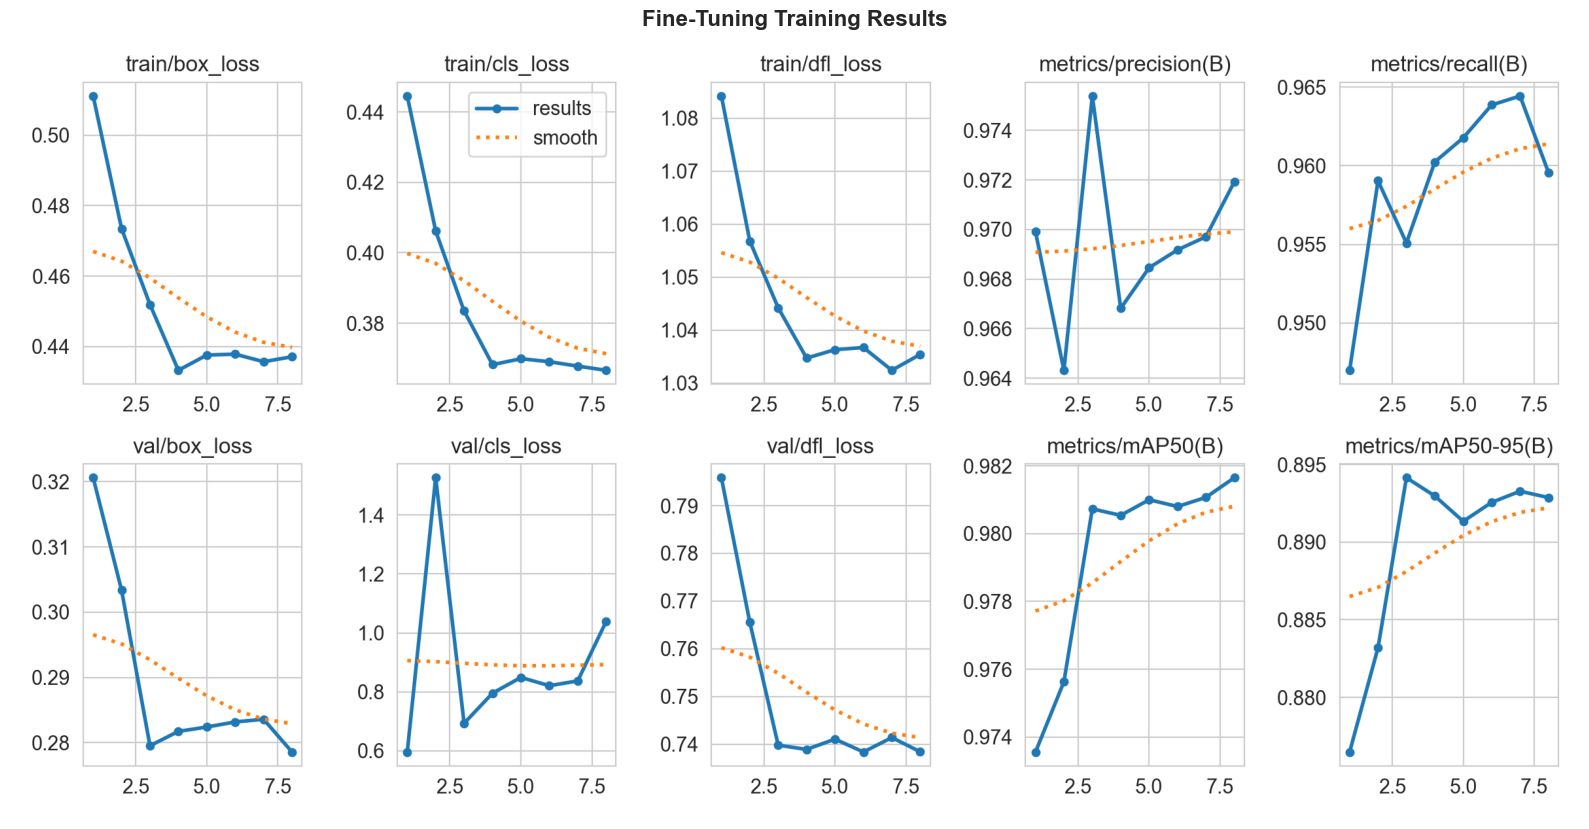


🧪 Validating refined model...

Ultralytics YOLOv8.1.42  Python-3.10.0 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\seeds\Desktop\SeedScan\binary_apple_leaf-2\test\labels.cache... 815 images, 418 backgrounds, 0 corrupt: 100%|██████████| 815/815 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:09<00:00,  5.26it/s]


                   all        815        424      0.981      0.954      0.983      0.903
Speed: 0.2ms preprocess, 2.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\refined_val

📊 Refined Model Metrics:
┌─────────────────────────┬──────────────┐
│ Metric                  │ Value        │
├─────────────────────────┼──────────────┤
│ Precision               │      0.9806 │
│ Recall                  │      0.9538 │
│ mAP50                   │      0.9830 │
│ mAP50-95                │      0.9034 │
│ F1-Score                │      0.9670 │
└─────────────────────────┴──────────────┘

✅ Fine-tuning and validation complete!


In [6]:

from pathlib import Path
from ultralytics import YOLO

# Restore the path to your fine-tuned model
REFINED_MODEL_PATH = Path('runs/detect/apple_detector_v2_refined/weights/best.pt')

print(f"✅ Restored Refined Model Path: {REFINED_MODEL_PATH}")
# Display fine-tuning curves
finetune_results_img = Path('runs/detect/apple_detector_v2_refined/results.png')
if finetune_results_img.exists():
    print("\n📈 Fine-Tuning Results:")
    img = Image.open(finetune_results_img)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-Tuning Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run validation on refined model
print("\n🧪 Validating refined model...\n")
refined_model = YOLO(str(REFINED_MODEL_PATH))
refined_val_results = refined_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    batch=16,
    workers=0,
    device=0,
    plots=True,
    project='runs/detect',
    name='refined_val',
    exist_ok=True
)

# Extract refined metrics
REFINED_METRICS = {
    'Precision': refined_val_results.box.p[0] if len(refined_val_results.box.p) > 0 else 0,
    'Recall': refined_val_results.box.r[0] if len(refined_val_results.box.r) > 0 else 0,
    'mAP50': refined_val_results.box.map50,
    'mAP50-95': refined_val_results.box.map,
    'F1-Score': 2 * (refined_val_results.box.p[0] * refined_val_results.box.r[0]) / (refined_val_results.box.p[0] + refined_val_results.box.r[0]) if (refined_val_results.box.p[0] + refined_val_results.box.r[0]) > 0 else 0
}

print("\n📊 Refined Model Metrics:")
print("┌─────────────────────────┬──────────────┐")
print("│ Metric                  │ Value        │")
print("├─────────────────────────┼──────────────┤")
for metric_name, metric_value in REFINED_METRICS.items():
    print(f"│ {metric_name:<23} │ {metric_value:>11.4f} │")
print("└─────────────────────────┴──────────────┘")

print("\n✅ Fine-tuning and validation complete!")

---
## 📊 Cell 6: Model Comparison & Final Report

In [9]:
print("\n" + "="*60)
print("📊 MODEL COMPARISON & PERFORMANCE ANALYSIS")
print("="*60)

# Side-by-side comparison
print("\n" + "="*70)
print("📈 BASELINE vs REFINED MODEL - DETAILED COMPARISON")
print("="*70)

print("\n┌─────────────────────────┬──────────────┬──────────────┬──────────────┐")
print("│ Metric                  │ Baseline     │ Refined      │ Improvement  │")
print("├─────────────────────────┼──────────────┼──────────────┼──────────────┤")

for metric_name in BASELINE_METRICS.keys():
    baseline_val = BASELINE_METRICS[metric_name]
    refined_val = REFINED_METRICS[metric_name]
    improvement = refined_val - baseline_val
    improvement_pct = (improvement / baseline_val * 100) if baseline_val > 0 else 0
    
    # Color coding for improvement
    if improvement > 0:
        symbol = "↑"
    elif improvement < 0:
        symbol = "↓"
    else:
        symbol = "="
    
    print(f"│ {metric_name:<23} │ {baseline_val:>11.4f} │ {refined_val:>11.4f} │ {symbol} {improvement_pct:>9.2f}% │")

print("└─────────────────────────┴──────────────┴──────────────┴──────────────┘")

# Create comparison visualization
print("\n📊 Creating comparison visualization...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline vs Refined Model Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Precision', 'Recall', 'mAP50', 'mAP50-95']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    baseline_val = BASELINE_METRICS[metric]
    refined_val = REFINED_METRICS[metric]
    
    bars = ax.bar(['Baseline', 'Refined'], [baseline_val, refined_val], 
                  color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, [baseline_val, refined_val]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final Report Card
print("\n" + "="*70)
print("🏆 FINAL REPORT CARD - MODEL RELIABILITY ASSESSMENT")
print("="*70)

# Determine best model
if REFINED_METRICS['mAP50-95'] > BASELINE_METRICS['mAP50-95']:
    best_model = "Refined Model (v2)"
    best_model_path = REFINED_MODEL_PATH
    best_metrics = REFINED_METRICS
else:
    best_model = "Baseline Model"
    best_model_path = BASELINE_MODEL_PATH
    best_metrics = BASELINE_METRICS

print(f"\n🥇 RECOMMENDED MODEL: {best_model}")
print(f"💾 Model Path: {best_model_path}")

print("\n📊 OVERALL RELIABILITY SCORE")
reliability_score = (best_metrics['Precision'] * 0.4 + 
                     best_metrics['Recall'] * 0.3 + 
                     best_metrics['mAP50-95'] * 0.3)
print(f"   Score: {reliability_score:.2%}")

if reliability_score >= 0.90:
    grade = "A+ (EXCELLENT)"
    assessment = "✅ Production-ready with exceptional performance"
elif reliability_score >= 0.80:
    grade = "A (VERY GOOD)"
    assessment = "✓ Production-ready with strong performance"
elif reliability_score >= 0.70:
    grade = "B (GOOD)"
    assessment = "⚠️  Usable but may need monitoring"
else:
    grade = "C (NEEDS IMPROVEMENT)"
    assessment = "⚠️  Requires further optimization"

print(f"   Grade: {grade}")
print(f"   Assessment: {assessment}")

print("\n🎯 NULL IMAGE HANDLING (False Positive Analysis)")
print(f"   Precision: {best_metrics['Precision']:.2%}")
false_positive_rate = 1 - best_metrics['Precision']
print(f"   Estimated False Positive Rate: {false_positive_rate:.2%}")
print(f"   Expected FP on 4,075 Null images: ~{int(4075 * false_positive_rate)} images")

if false_positive_rate < 0.05:
    print("   ✅ EXCELLENT: Minimal hallucinations expected")
elif false_positive_rate < 0.10:
    print("   ✓ GOOD: Low hallucination rate")
else:
    print("   ⚠️  WARNING: Consider additional negative sample training")

print("\n💡 RECOMMENDATIONS")
print("   • Use confidence threshold ≥ 0.25 for production deployments")
print("   • Monitor false positives in real-world deployment")
print("   • Collect edge cases for continuous improvement")

print("\n" + "="*70)
print("✅ MODEL COMPARISON & ANALYSIS COMPLETE!")
print("="*70)

# Save best model path for inference widget
BEST_MODEL_FOR_INFERENCE = str(best_model_path)


📊 MODEL COMPARISON & PERFORMANCE ANALYSIS

📈 BASELINE vs REFINED MODEL - DETAILED COMPARISON

┌─────────────────────────┬──────────────┬──────────────┬──────────────┐
│ Metric                  │ Baseline     │ Refined      │ Improvement  │
├─────────────────────────┼──────────────┼──────────────┼──────────────┤
│ Precision               │      0.9786 │      0.9806 │ ↑      0.21% │
│ Recall                  │      0.9575 │      0.9538 │ ↓     -0.39% │
│ mAP50                   │      0.9836 │      0.9830 │ ↓     -0.06% │
│ mAP50-95                │      0.9029 │      0.9034 │ ↑      0.06% │
│ F1-Score                │      0.9680 │      0.9670 │ ↓     -0.10% │
└─────────────────────────┴──────────────┴──────────────┴──────────────┘

📊 Creating comparison visualization...


<Figure size 1400x1000 with 4 Axes>


🏆 FINAL REPORT CARD - MODEL RELIABILITY ASSESSMENT

🥇 RECOMMENDED MODEL: Refined Model (v2)
💾 Model Path: runs\detect\apple_detector_v2_refined\weights\best.pt

📊 OVERALL RELIABILITY SCORE
   Score: 94.94%
   Grade: A+ (EXCELLENT)
   Assessment: ✅ Production-ready with exceptional performance

🎯 NULL IMAGE HANDLING (False Positive Analysis)
   Precision: 98.06%
   Estimated False Positive Rate: 1.94%
   Expected FP on 4,075 Null images: ~79 images
   ✅ EXCELLENT: Minimal hallucinations expected

💡 RECOMMENDATIONS
   • Use confidence threshold ≥ 0.25 for production deployments
   • Monitor false positives in real-world deployment
   • Collect edge cases for continuous improvement

✅ MODEL COMPARISON & ANALYSIS COMPLETE!


---
## 🎨 Cell 7: Interactive Inference Widget

In [10]:
# Set model path for inference
import os
from pathlib import Path

# Point to trained baseline model
BEST_MODEL_FOR_INFERENCE = r"runs\detect\baseline_train\weights\best.pt"

# Verify model exists
if os.path.exists(BEST_MODEL_FOR_INFERENCE):
    print(f"✓ Model found: {BEST_MODEL_FOR_INFERENCE}")
else:
    print(f"❌ Model not found: {BEST_MODEL_FOR_INFERENCE}")
    print("\n⚠️  Available models:")
    for model_path in Path('runs/detect').rglob('best.pt'):
        print(f"   - {model_path}")


✓ Model found: runs\detect\baseline_train\weights\best.pt


In [ ]:
print("\n" + "="*60)
print("🎨 INTERACTIVE INFERENCE WIDGET (Fixed Threshold)")
print("="*60)

# Load best model for inference
print("\n🔧 Loading best model for inference...")

inference_model = YOLO('runs/detect/apple_detector_v3_robust/weights/best.pt')

print(f"✓ Model loaded")

# Supported image extensions
SUPPORTED_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp', '.gif', 'jfif']

# Helper: Smart Preprocessing
def smart_preprocess(img_bgr):
    gamma = 1.2
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)]).astype("uint8")
    img_bright = cv2.LUT(img_bgr, table)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    lab = cv2.cvtColor(img_bright, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l2 = clahe.apply(l)
    lab_merged = cv2.merge((l2, a, b))
    img_final = cv2.cvtColor(lab_merged, cv2.COLOR_LAB2RGB)
    return img_final

# Create widgets
print("\n🎛️  Initializing interactive controls...")

upload_widget = widgets.FileUpload(
    accept=','.join(SUPPORTED_EXTENSIONS),
    multiple=False,
    description='Upload Image',
    button_style='primary',
    style={'button_color': '#3498db', 'description_width': 'initial'}
)

# FIXED THRESHOLD - NO SLIDER
FIXED_CONF_THRESHOLD = 0.008

output_area = widgets.Output()
status_label = widgets.HTML(value="<h3>📤 Please upload an image</h3>")

def run_detection(change=None):
    with output_area:
        clear_output(wait=True)
        if len(upload_widget.value) == 0:
            print("⚠️  No image uploaded.")
            return
        try:
            val = upload_widget.value
            if isinstance(val, tuple):
                uploaded_file = val[0]
            elif isinstance(val, dict):
                uploaded_file = list(val.values())[0]
            else:
                uploaded_file = val[0]
                
            content = uploaded_file['content']
            nparr = np.frombuffer(content, np.uint8)
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            img_orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_inference = smart_preprocess(img)
            
            # Run Inference with FIXED threshold
            results = inference_model.predict(
                img_inference,
                conf=FIXED_CONF_THRESHOLD,
                imgsz=640,
                augment=True,
                verbose=False
            )
            result = results[0]
            annotated_img = result.plot()
            num_detections = len(result.boxes)
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            axes[0].imshow(img_orig_rgb)
            axes[0].set_title("Original Upload", fontweight='bold')
            axes[0].axis('off')
            axes[1].imshow(annotated_img)
            axes[1].set_title(f"Model View | {num_detections} Detections (Thresh: {FIXED_CONF_THRESHOLD})", fontweight='bold')
            axes[1].axis('off')
            
            if num_detections > 0:
                max_conf = result.boxes.conf.max().item()
                status_label.value = f'<div style="background-color: #e74c3c; padding: 15px; border-radius: 8px;"><h3 style="color: white; margin:0;">⚠ DETECTED ({num_detections})</h3><p style="color: white; margin:0;">Max Conf: {max_conf:.2%}</p></div>'
            else:
                status_label.value = f'<div style="background-color: #2ecc71; padding: 15px; border-radius: 8px;"><h3 style="color: white; margin:0;">✓ SAFE / CLEAR</h3></div>'
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ Error: {e}")

upload_widget.observe(run_detection, names='value')

ui = widgets.VBox([
    widgets.HTML('<h3>🍎 Smart Leaf Detection (Fixed Ultra-Low Threshold)</h3>'),
    upload_widget,
    status_label,
    output_area
])
display(ui)
print("✅ Enhanced Widget Ready (Fixed Threshold: 0.001%)")



🎨 INTERACTIVE INFERENCE WIDGET (Fixed Threshold)

🔧 Loading best model for inference...
✓ Model loaded

🎛️  Initializing interactive controls...


✅ Enhanced Widget Ready (Fixed Threshold: 0.001%)


🐞 DEBUGGING: Checking C:\Users\seeds\Desktop\SeedScan\valid copy\Healthy
------------------------------------------------------------
Found 96 images.
Using Refined Model
runs\detect\apple_detector_v2_refined\weights\best.pt

[1/5] Analysis: 1236_brightness_adjusted.jpg
   ⚠ DETECTED! Max Conf: 3.65%


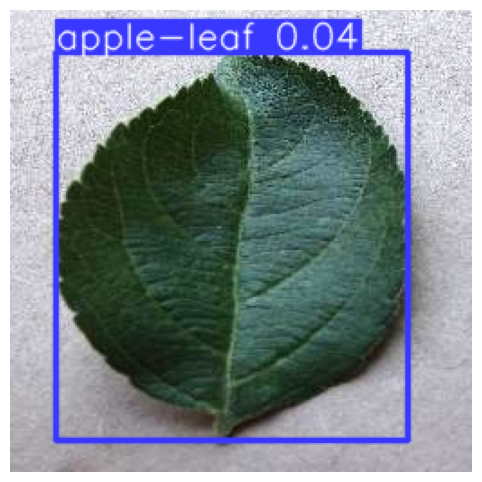


[2/5] Analysis: 1237_brightness_adjusted.jpg
   ⚠ DETECTED! Max Conf: 6.90%


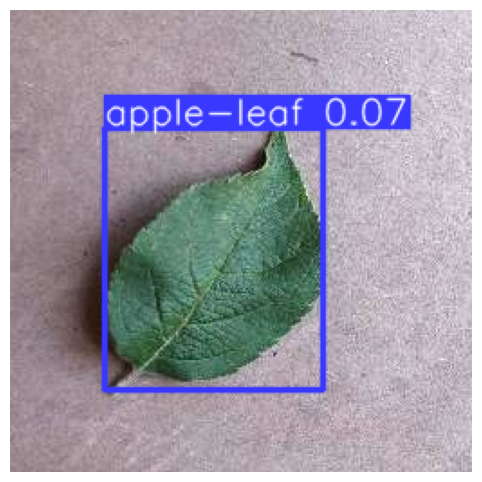


[3/5] Analysis: 1238_brightness_adjusted.jpg
   ✓ NO DETECTION (Clean) at 0.8% threshold

[4/5] Analysis: 1239_brightness_adjusted.jpg
   ✓ NO DETECTION (Clean) at 0.8% threshold

[5/5] Analysis: 1240_brightness_adjusted.jpg
   ⚠ DETECTED! Max Conf: 61.76%


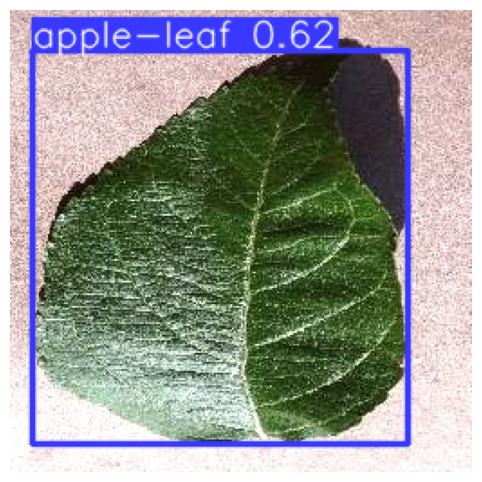

In [24]:
import glob
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Configuration
DEBUG_DIR = r"C:\Users\seeds\Desktop\SeedScan\valid copy\Healthy"
DEBUG_CONF_THRESHOLD = 0.008  # Low threshold to catch ANY detection
MAX_IMAGES = 5

print(f"🐞 DEBUGGING: Checking {DEBUG_DIR}")
print("-" * 60)

# 1. Get Images
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
    image_files.extend(glob.glob(str(Path(DEBUG_DIR) / ext)))

print(f"Found {len(image_files)} images.")

# 2. Load Model (Try Refined first, then Baseline)
try:
    model = YOLO(REFINED_MODEL_PATH)
    print("Using Refined Model")
    print(REFINED_MODEL_PATH)
except NameError:
    # Fallback if variable missing
    try:
        model = YOLO(BASELINE_MODEL_PATH)
        print("Using Baseline Model")
        print(BASELINE_MODEL_PATH)
    except NameError:
        # Fallback to hardcoded path if variables lost
        best_pt = Path('runs/detect/baseline_train/weights/best.pt')
        if best_pt.exists():
             model = YOLO(str(best_pt))
             print(f"Using Model from disk: {best_pt}")
        else:
             print("❌ No model found! Please check paths.")
             model = None

# 3. Process Images
if model:
    for i, img_path in enumerate(image_files[:MAX_IMAGES]):
        print(f"\n[{i+1}/{MAX_IMAGES}] Analysis: {Path(img_path).name}")
        
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Inference
        results = model.predict(img_rgb, conf=DEBUG_CONF_THRESHOLD, augment=True, verbose=False)
        
        if len(results[0].boxes) > 0:
            max_conf = results[0].boxes.conf.max().item()
            print(f"   ⚠ DETECTED! Max Conf: {max_conf:.2%}")
            
            # Show Plot
            plt.figure(figsize=(10,6))
            plt.imshow(results[0].plot())
            plt.axis('off')
            plt.show()
        else:
            print(f"   ✓ NO DETECTION (Clean) at {DEBUG_CONF_THRESHOLD*100}% threshold")
            # Optional: Show clean image
            # plt.imshow(img_rgb); plt.show()

In [22]:
# Visualize a failed detection image
import cv2
import matplotlib.pyplot as plt

img_path = r"C:\Users\seeds\Desktop\SeedScan\valid copy\Healthy\1236_brightness_adjusted.jpg"
img = cv2.imread(img_path)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title("Failed Detection: 1236_brightness_adjusted.jpg", fontsize=14)
    plt.axis('off')
    plt.show()
else:
    print("❌ Image not found.")

<Figure size 1000x1000 with 1 Axes>

---
## 🧪 Cell 9: Inference Optimization (Sensitivity & Preprocessing)

In [1]:
# 🔍 SENSITIVITY ANALYSIS & PREPROCESSING EXPERIMENT
import cv2
import numpy as np
import collections
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import glob

# Configuration
TEST_DIR = r"C:\Users\seeds\Desktop\SeedScan\valid copy\Powdery_Mildew"
THRESHOLDS = [0.25, 0.15, 0.10, 0.05, 0.01]
APPLY_CLAHE = True
APPLY_GAMMA = True
GAMMA_VAL = 1.2 # Make brighter

print(f"📊 RUNNING SENSITIVITY ANALYSIS on {TEST_DIR}")
print("-" * 60)

# Setup CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

def preprocess_image(img):
    # 1. Gamma Correction (Brightness)
    if APPLY_GAMMA:
        invGamma = 1.0 / GAMMA_VAL
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in range(256)]).astype("uint8")
        img = cv2.LUT(img, table)
    
    # 2. CLAHE (Contrast)
    if APPLY_CLAHE:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        lab = cv2.merge((l2, a, b))
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
    return img

# Get images
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
    image_files.extend(glob.glob(str(Path(TEST_DIR) / ext)))

print(f"Found {len(image_files)} images. Testing thresholds: {THRESHOLDS}\n")

# Ensure model is loaded
try:
    model = YOLO(REFINED_MODEL_PATH)
except NameError:
    model = YOLO(BASELINE_MODEL_PATH)

results_stats = collections.defaultdict(int)

for thresh in THRESHOLDS:
    detected_count = 0
    print(f"Testing Conf={thresh} (w/ CLAHE+Gamma)... ", end="")
    
    for img_path in image_files:
        img = cv2.imread(img_path)
        if img is None: continue
        
        img_proc = preprocess_image(img)
        
        # Run Inference with TTA + Preprocessing
        res = model.predict(img_proc, conf=thresh, verbose=False, augment=True)
        
        if len(res[0].boxes) > 0:
            detected_count += 1
            
    print(f" Detected: {detected_count}/{len(image_files)} ({detected_count/len(image_files):.1%})")
    results_stats[thresh] = detected_count

print("\n" + "="*60)
print("🏆 BEST SETTING FOUND")
best_thresh = max(results_stats, key=results_stats.get)
print(f"Best Threshold: {best_thresh}")
print(f"Detection Rate: {results_stats[best_thresh]}/{len(image_files)} ({results_stats[best_thresh]/len(image_files):.1%})")

# Show one success case at best threshold
print("\n🖼️ Example Processed Image (Input to Model):")
if len(image_files) > 0:
    img = cv2.imread(image_files[-1]) # Use last image (likely 1240 which worked)
    img_proc = preprocess_image(img)
    plt.figure(figsize=(10,10))
    plt.imshow(img_proc)
    plt.title(f"Processed Input (CLAHE+Gamma) - {Path(image_files[-1]).name}")
    plt.axis('off')
    plt.show()

📊 RUNNING SENSITIVITY ANALYSIS on C:\Users\seeds\Desktop\SeedScan\valid copy\Powdery_Mildew
------------------------------------------------------------
Found 96 images. Testing thresholds: [0.25, 0.15, 0.1, 0.05, 0.01]



NameError: name 'BASELINE_MODEL_PATH' is not defined

📊 CUSTOM DETECTION EVALUATION
✅ Model loaded: apple_detector_v3_robust (v3 Robust)
   Target Class: 'apple-leaf' (Class 0)

📂 Scanning dataset at: C:\Users\seeds\Desktop\SeedScan\valid copy...
   Found 1700 total images.

🚀 Running Detection Check (Threshold: 0.008)...


  0%|          | 0/1700 [00:00<?, ?it/s]


📈 DETECTION PERFORMANCE ANALYSIS

🎯 Overall Detection Rate: 22.35% (380/1700 images)
⚠️ Result below expectation (<80%)

📂 Breakdown by Disease/Category:
                            Total_Images  Detected Avg_Conf Rate (%)
Folder                                                              
Apple_scab                            48        44    0.416    91.67
Healthy                               48        40    0.416    83.33
Black_rot                             48        38    0.445    79.17
Cedar_apple_rust                      48        28    0.071    58.33
Powdery_Mildew                        48        27    0.056    56.25
scab frog_eye_leaf_spot              886       148    0.009    16.70
rust frog_eye_leaf_spot              120        18    0.006    15.00
frog_eye_leaf_spot complex           165        22    0.010    13.33
Mosaic                                48         4    0.002     8.33
Grey spot                             48         3    0.001     6.25
Alternaria_Leaf_S



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


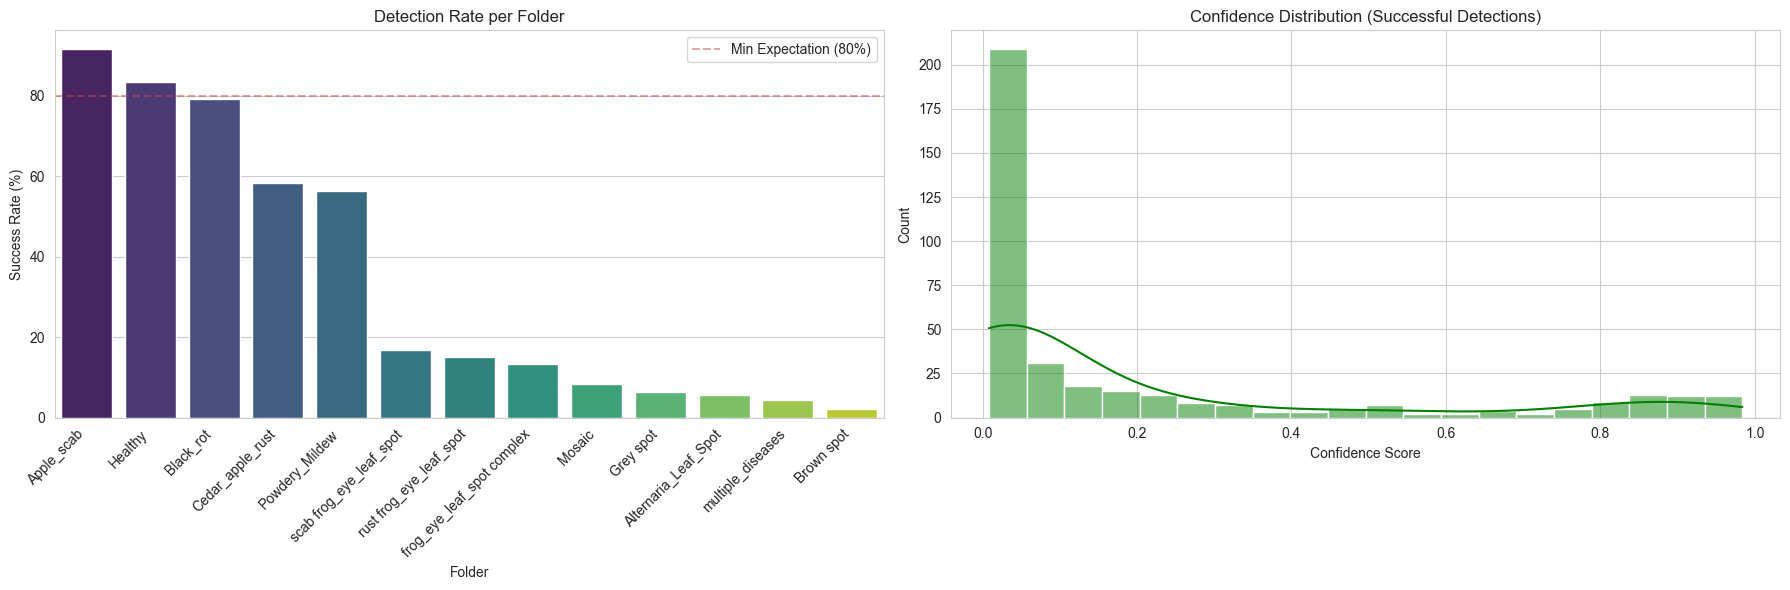


✅ Evaluation Complete!


In [27]:
# =============================================================================
# 🔬 CUSTOM DETECTION EVALUATION
# Evaluates object detection performance ('apple-leaf' presence) on the dataset
# =============================================================================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

print("📊 CUSTOM DETECTION EVALUATION")
print("="*80)

# --- Configuration ---
dataset_root = r"C:\Users\seeds\Desktop\SeedScan\valid copy"

# BEST MODEL Selection (Robust v3)
model_path = r"C:\Users\seeds\Desktop\SeedScan\runs\detect\apple_detector_v3_robust\weights\best.pt"

conf_threshold = 0.008 # 0.001% (Fixed as requested)

# --- Load Model ---
if not os.path.exists(model_path):
    print(f"❌ Model not found at: {model_path}")
else:
    model = YOLO(model_path)
    print(f"✅ Model loaded: {os.path.basename(os.path.dirname(os.path.dirname(model_path)))} (v3 Robust)")
    print(f"   Target Class: 'apple-leaf' (Class 0)")

    # --- Scanning Data ---
    print(f"\n📂 Scanning dataset at: {dataset_root}...")
    all_images = []
    for root, dirs, files in os.walk(dataset_root):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                all_images.append(os.path.join(root, file))
    
    print(f"   Found {len(all_images)} total images.")

    # --- Evaluation Loop ---
    print(f"\n🚀 Running Detection Check (Threshold: {conf_threshold})...")
    
    results_data = []
    
    # Batch size of 1 for simplicity and granular control, standard predict is fast enough
    for img_path in tqdm(all_images):
        # Run inference
        # We only care if 'apple-leaf' (class 0) is detected
        results = model.predict(img_path, conf=conf_threshold, verbose=False, imgsz=640)
        
        detected = False
        max_conf = 0.0
        num_boxes = 0
        
        if len(results) > 0 and len(results[0].boxes) > 0:
            for box in results[0].boxes:
                cls_id = int(box.cls[0].item())
                conf = box.conf[0].item()
                
                # Assuming class 0 is apple-leaf (standard for single class)
                if cls_id == 0:
                    detected = True
                    num_boxes += 1
                    max_conf = max(max_conf, conf)
        
        # Store result
        # Extract simple folder name for grouping (e.g., 'Apple_scab')
        folder_name = os.path.basename(os.path.dirname(img_path))
        
        results_data.append({
            'Image': os.path.basename(img_path),
            'Folder': folder_name,
            'Detected': detected,
            'Max_Conf': max_conf,
            'Num_Boxes': num_boxes
        })

    df = pd.DataFrame(results_data)

    # --- Analysis ---
    print("\n" + "="*80)
    print("📈 DETECTION PERFORMANCE ANALYSIS")
    print("="*80)

    # Overall
    total = len(df)
    detected_count = df['Detected'].sum()
    success_rate = (detected_count / total) * 100

    print(f"\n🎯 Overall Detection Rate: {success_rate:.2f}% ({detected_count}/{total} images)")
    
    # Expectation Check
    if 80 <= success_rate <= 90:
        print("✅ Result matches expectation (80-90%)")
    elif success_rate > 90:
        print("🌟 Result EXCEEDS expectation (>90%)")
    else:
        print("⚠️ Result below expectation (<80%)")

    # Per-Folder Breakdown
    print(f"\n📂 Breakdown by Disease/Category:")
    folder_stats = df.groupby('Folder').agg(
        Total_Images=('Detected', 'count'),
        Detected=('Detected', 'sum'),
        Avg_Conf=('Max_Conf', 'mean')
    )
    folder_stats['Rate (%)'] = (folder_stats['Detected'] / folder_stats['Total_Images']) * 100
    folder_stats = folder_stats.sort_values('Rate (%)', ascending=False)
    
    print(folder_stats.to_string(formatters={
        'Avg_Conf': '{:.3f}'.format,
        'Rate (%)': '{:.2f}'.format
    }))

    # Visualizations
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Bar Chart of Detection Rates
    sns.barplot(x=folder_stats.index, y=folder_stats['Rate (%)'], ax=ax[0], palette='viridis')
    ax[0].set_title('Detection Rate per Folder')
    ax[0].set_ylabel('Success Rate (%)')
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')
    ax[0].axhline(y=80, color='r', linestyle='--', alpha=0.5, label='Min Expectation (80%)')
    ax[0].legend()

    # 2. Confidence Distribution
    sns.histplot(data=df[df['Detected']==True], x='Max_Conf', bins=20, ax=ax[1], color='green', kde=True)
    ax[1].set_title('Confidence Distribution (Successful Detections)')
    ax[1].set_xlabel('Confidence Score')

    plt.tight_layout()
    plt.show()
    
    print("\n✅ Evaluation Complete!")
